In [1]:
#%%

import tensorflow as tf
import pandas as pd
import numpy as np
# from utils.dataset import load_bioarxiv_dataset,partitions, Datagen
from model import Model_TE_aug_decoders, custom_build
#new import 
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as an
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white')
sc.logging.print_header()
import pandas as pd
import pylab
import matplotlib
from sklearn.model_selection import StratifiedKFold
def color_cm(cmap,NUM_COLORS,):
    color = []
    color_idx = 0
    cm = pylab.get_cmap(cmap)
    for i in range(NUM_COLORS):
        color.append(matplotlib.colors.to_hex(cm(1. * i / NUM_COLORS)))  # color will now be an RGBA tuple
    return color
def partitions(celltype, n_partitions, seed=0):
    """Create stratified cross validation sets, based on `cluster` annotations.
    Indices of the n-th fold are `ind_dict[n]['train']` and `ind_dict[n]['val']`.
    Assumes `celltype` has the same samples as in the dataset.

    Args:
        celltype: numpy array with celltype annotations for all dataset samples
        n_partitions: number of partitions (e.g. cross validation folds)
        seed: random seed used for partitioning.

    Returns:
        ind_dict: list with `n_partitions` dict elements.
    """
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)

    # Safe to ignore warning - there are celltypes with a low sample number that are not crucial for the analysis.
    with warnings.catch_warnings():
        skf = StratifiedKFold(n_splits=n_partitions, random_state=seed, shuffle=True)

    # Get all partition indices from the sklearn generator:
    ind_dict = [{'train': train_ind, 'val': val_ind} for train_ind, val_ind in
                skf.split(X=np.zeros(shape=celltype.shape), y=celltype)]
    return ind_dict

scanpy==1.6.0 anndata==0.7.5 numpy==1.19.3 scipy==1.4.1 pandas==1.2.0 scikit-learn==0.24.0 statsmodels==0.12.1 python-igraph==0.8.3 louvain==0.7.0 leidenalg==0.8.3


In [2]:


spe_gene = ['SLC8A1', 'VDAC3', 'SLC16A1','SLC2A1','ATP2A2','KCND3','NIPAL1',
              'HCN4','KCNK6','VCL','MYH7','VDAC2','SMPX','LBH','GATA4',
           'SLC44A2','FHL1','VIM','S100A4','TNNT2','RYR2','WNT2',
           'MYH6','KDR']

def findgenes(gene_list):
    #Find location of all genes
    gene_inds = []
    for gene in gene_list:
        ind = np.flatnonzero(np.isin(gene_train_4d_df.index.values,gene))
        if ind.size==1:
            gene_inds.append(ind[0])
    gene_inds_co = np.array(gene_inds)
    genes_found = gene_train_4d_df.index.values[gene_inds].tolist()
    return genes_found,gene_inds
from sklearn.model_selection import train_test_split


In [1]:

gene_train_4d_df = pd.read_csv('./data/contact_data/gene_data_dpc.csv',header=0,index_col=0)
gene_names = gene_train_4d_df.index

gene_4d_stage_all = np.array([vl.split('_')[0] for vl in gene_train_4d_df.columns.values])
gene_4d_stage_unq = np.unique(gene_4d_stage_all)
gene_4d_cl = color_cm('rainbow',len(gene_4d_stage_unq))
stage_cl = dict(zip(gene_4d_stage_unq,gene_4d_cl))
# gene_4d_stage_cl = np.vectorize(stage_cl.get)(gene_4d_stage_all)
gene_train_4d = gene_train_4d_df.values.T
ephys_train_4d = pd.read_csv('./data/contact_data/ephys_data_dpc.csv',header=0,index_col=0).values.T

ind_dict = partitions(gene_4d_stage_all, n_partitions=5, seed=0)
cor_ErE = []
cor_TrT = []
cor_ErE_cm = []
cor_TrT_cm = []
data_in = []
cv_all = []
method = []

for cv in range(5):
    stage_cl = dict(zip(gene_4d_stage_unq,gene_4d_cl))

    train_ind, val_ind = ind_dict[cv]['train'], ind_dict[cv]['val']
    XT = gene_train_4d[train_ind,:]
    XT_test = gene_train_4d[val_ind,:]

    XE = ephys_train_4d[train_ind,:]
    XE_test = ephys_train_4d[val_ind,:]

    gene_4d_stage = gene_4d_stage_all[train_ind]
    gene_hb_stage = gene_4d_stage_all[val_ind]

    gene_4d_stage_cl = np.vectorize(stage_cl.get)(gene_4d_stage)

    median_T = np.median(XT.sum(axis=1))
    XT = XT/XT.sum(axis=1)[:, np.newaxis]*median_T
    XT = np.log1p(XT)
    XT = np.nan_to_num(XT)
    T_dim = XT.shape[1]
    E_dim = XE.shape[1]


    XT_test = XT_test/XT_test.sum(axis=1)[:, np.newaxis]*median_T
    XT_test = np.log1p(XT_test)
    XT_test = np.nan_to_num(XT_test)
    #Training step
    @tf.function
    def train_fn(model, optimizer, xt, xe):
        with tf.GradientTape() as tape:
            zT, zE, XrT, XrE, XrT_cm, XrE_cm = model((xt, xe),
                                    train_T=True, 
                                    train_E=True,
                                    augment_decoders=True)

            trainable_weights = [weight for weight in model.trainable_weights]
            loss = sum(model.losses)

        grads = tape.gradient(loss, trainable_weights)
        optimizer.apply_gradients(zip(grads, trainable_weights))
        return zT, zE, XrT, XrE 
    #Print losses calculated. These are MSE calculations that do not include the  
    def report_metrics(model, epoch, losstype):
        print('{:10s} Epoch:{:5d}, '
                'mse_T: {:0.3f}, '
                'mse_E: {:0.3f}, '
                'mse_TE: {:0.3f}'.format(losstype,epoch,
                                        model.mse_loss_T.numpy(),
                                        model.mse_loss_E.numpy(),
                                        model.mse_loss_TE.numpy()))
        return model.mse_loss_T.numpy()+model.mse_loss_E.numpy()+model.mse_loss_TE.numpy()
    def cal_correlation(XE, XT, XrE, XrT, XrE_cm, XrT_cm):
        ErE = []
        TrT = []
        ErE_cm = []
        TrT_cm = []
        XE = tf.where(tf.math.is_nan(XE), x=0.0, y=XE)
        for i in range(0, XE.shape[0]):
            ErE_cor = np.corrcoef(XE[i, :], XrE[i, :])
            TrT_cor = np.corrcoef(XT[i, :], XrT[i, :])
            ErE_cm_cor = np.corrcoef(XE[i, :], XrE_cm[i, :])
            TrT_cm_cor = np.corrcoef(XT[i, :], XrT_cm[i, :])
            ErE.append(ErE_cor[0, 1])
            TrT.append(TrT_cor[0, 1])
            ErE_cm.append(ErE_cm_cor[0, 1])
            TrT_cm.append(TrT_cm_cor[0, 1])
        print(sum(ErE) / len(ErE), len(ErE))
        print(sum(TrT) / len(TrT), len(TrT))
        print(sum(ErE_cm) / len(ErE_cm), len(ErE_cm))
        print(sum(TrT_cm) / len(TrT_cm), len(TrT_cm))
        cor_ErE = sum(ErE) / len(ErE)
        cor_TrT = sum(TrT) / len(TrT)
        cor_ErE_cm = sum(ErE_cm) / len(ErE_cm)
        cor_TrT_cm = sum(TrT_cm) / len(TrT_cm)
        return cor_ErE,cor_TrT,cor_ErE_cm,cor_TrT_cm
    ## train the model with no normalized data with correct pair

    # tf.config.run_functions_eagerly(True)
    from utils.dataset import load_bioarxiv_dataset,partitions, Datagen
    seed = 42
    tf.random.set_seed(seed)
    batchsize = 10
    n_epochs = 20
    n_steps_per_epoch = 1000
    maxsteps = n_epochs*n_steps_per_epoch

    #Load and build model
    cplAE = Model_TE_aug_decoders(T_dim,E_dim,latent_dim=2)
    cplAE = custom_build(cplAE,(T_dim,E_dim))

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)#3)
    train_generator = tf.data.Dataset.from_generator(Datagen,output_types=(tf.float32, tf.float32),
                                                     args=(maxsteps,batchsize,XT,XE))
    epoch=0
    loss_train = []
    loss_val = []
    for step, (xT,xE) in enumerate(train_generator):
        train_fn(model=cplAE,optimizer=adam_optimizer,xt=xT,xe=xE)

        #Report training loss
        if (step+1) % n_steps_per_epoch == 0:
            cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), 
                  train_T=False, train_E=False)
            loss_train.append(report_metrics(model=cplAE ,epoch=epoch, losstype='Train'))

            cplAE((tf.constant(XT_test,dtype=tf.float32), tf.constant(XE_test,dtype=tf.float32)),
                  train_T=False, train_E=False)
            loss_val.append(report_metrics(model=cplAE ,epoch=epoch, losstype='Val.'))

            epoch=epoch+1


    zE_lim = [[-3,3],[-3,3.5]]
    zT_lim = zE_lim
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(16,8))
    sz=30
    plt.subplot(1,2,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_4d_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,2,2)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()
    plt.savefig(f'./singlecellfigures/Training4DayManifoldCV{cv}.pdf')
    plt.show()



    genes_found_spe,gene_inds_spe = findgenes(spe_gene)

    gene_id_dict = {'all':np.arange(201),
                   'spe':gene_inds_spe}


    from scipy import stats
    XT1 = XT
    XE1 = XE
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm
    for dt in ['all','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('training')
        data_in.append(dt)
        cv_all.append(cv)

    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)
    plt.savefig(f'./singlecellfigures/Training4DayCorrelationCV{cv}.pdf')
    plt.show()
    metrics_df_training = pd.DataFrame({'trans/rec':['ErE','TrT','ErE_cm','TrT_cm'],
                              "Pearson's R":[cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_]})

    gene_hb_stage_unq = gene_4d_stage_unq
    gene_hb_stage_cl = np.vectorize(stage_cl.get)(gene_hb_stage)
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(32,8))
    sz=30
    plt.subplot(1,4,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz)
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Four day transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,4,3)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Four day Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()

    # gene_hb_stage_unq = ['day64']

    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT_test,dtype=tf.float32), tf.constant(XE_test,dtype=tf.float32)), train_T=False, train_E=False)

    zT = zT.numpy()
    zE = zE.numpy()
    #Plot representations
    # plt.figure(figsize=(16,8))

    plt.subplot(1,4,2)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_hb_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Testing four days transcriptomic bottleneck representation')
    plt.legend()
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.subplot(1,4,4)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_hb_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Testing four days Electrophysiology bottleneck representation')
    plt.legend()
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.savefig(f'./singlecellfigures/ValidationTestingFourdaysVerificationManifoldCV{cv}.pdf')
    plt.show()


    from scipy import stats
    XT1 = XT_test
    XE1 = XE_test
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm

    for dt in ['all','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('self-splitting')
        data_in.append(dt)
        cv_all.append(cv)


    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)

    plt.savefig(f'./singlecellfigures/ValidationTestingFourdaysCorrelationCV{cv}.pdf')
    plt.show()
    metrics_df_self_testing = pd.DataFrame({'trans/rec':['ErE','TrT','ErE_cm','TrT_cm'],
                              "Pearson's R":[cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_]})

    # testing new day 64 sample

    gene_train_hb_df = pd.read_csv('../SupplementaryExperiment/2_Cardiac Mixed sample/results/gene_data_dpc_device18_integrated.csv',header=0,index_col=0)
    gene_train_hb_df.columns = gene_names
    # gene_train_hb_df = gene_train_hb_df[rrr_genes]
    gene_train_hb_df.index=[f'day64_{i}' for i in range(17)]
    gene_hb_stage = np.array(gene_train_hb_df.shape[0]*['day64'])
    gene_hb_stage_unq = np.unique(gene_hb_stage)
    gene_hb_cl = color_cm('summer',len(gene_hb_stage_unq))
    stage_cl = dict(zip(gene_hb_stage_unq,gene_hb_cl))
    gene_hb_stage_cl = np.vectorize(stage_cl.get)(gene_hb_stage)

    gene_val_hb = gene_train_hb_df.values.T
    ephys_val_hb = pd.read_csv('../SupplementaryExperiment/2_Cardiac Mixed sample/results/ephys_data_dpc_device18_integrated.csv',header=0,index_col=0).values.T

    XT_test2 = gene_val_hb.T
    
    
    XE_test2 = ephys_val_hb.T

    XT_test2 = XT_test2/XT_test2.sum(axis=1)[:, np.newaxis]*median_T
    XT_test2 = np.log1p(XT_test2)
    XT_test2 = np.nan_to_num(XT_test2)
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(32,8))
    sz=30
    plt.subplot(1,4,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_4d_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Four day transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,4,3)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Four day Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()

    gene_hb_stage_unq = ['day64']

    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT_test2,dtype=tf.float32), tf.constant(XE_test2,dtype=tf.float32)), train_T=False, train_E=False)

    zT = zT.numpy()
    zE = zE.numpy()
    #Plot representations
    # plt.figure(figsize=(16,8))

    plt.subplot(1,4,2)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_hb_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('New day 64 transcriptomic bottleneck representation')
    plt.legend()
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.subplot(1,4,4)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_hb_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('New day 64 Electrophysiology bottleneck representation')
    plt.legend()
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.savefig(f'./singlecellfigures/NewDay64VerificationManifoldCV{cv}.pdf')
    plt.show()

    XT1 = XT_test2
    XE1 = XE_test2
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm
    for dt in ['all','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('new-day-64')
        data_in.append(dt)
        cv_all.append(cv)

    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)

    plt.show()



In [46]:
pearson_df = pd.DataFrame({'E2E':cor_ErE,'T2T':cor_TrT,'T2E':cor_ErE_cm,'E2T':cor_TrT_cm,
             'method':method,'data_in':data_in,'cv':cv_all})
pearson_df = pearson_df.melt(id_vars=['method','cv','data_in'],value_vars=['E2E','T2E','T2T','E2T'],var_name='Translation/Reconstruction', value_name='Pearsons R')



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

for dt in ['all','spe']:
    fig,ax=plt.subplots(figsize=[5,4])
    g = sns.barplot(data = pearson_df[pearson_df['data_in']==dt], x='Translation/Reconstruction',y='Pearsons R',hue='method',#hue_order =hue_order,
                   palette='Blues',alpha=0.5,ax=ax)
    sns.swarmplot(data = pearson_df[pearson_df['data_in']==dt], x='Translation/Reconstruction',y='Pearsons R',hue='method',#hue_order =hue_order,
                   palette='Blues',dodge=True,ax=g)
    plt.ylabel("Pearson R")
    plt.legend(bbox_to_anchor=(1.02, 0.7), loc='upper left', borderaxespad=0)
#     plt.title(dt)
    plt.ylim([0,1])
    plt.savefig(f'./singlecellfigures/prediction_summary_PearsonR{dt}.pdf')




In [70]:
r_selected = pearson_df[(pearson_df['data_in']=='ion')&(pearson_df['Translation/Reconstruction']=='E2T')]

r_split = r_selected[r_selected['method']=='self-splitting']['Pearsons R']
r_day64 = r_selected[r_selected['method']=='new-day-64']['Pearsons R']
print(f'self spliting r mean: {r_split.mean()}, r std: {r_split.std()}')
print(f'day 64 r mean: {r_day64.mean()}, r std: {r_day64.std()}')



self spliting r mean: 0.7497163452174698, r std: 0.013172833122981497
day 64 r mean: 0.7254969676756513, r std: 0.008811793964717743


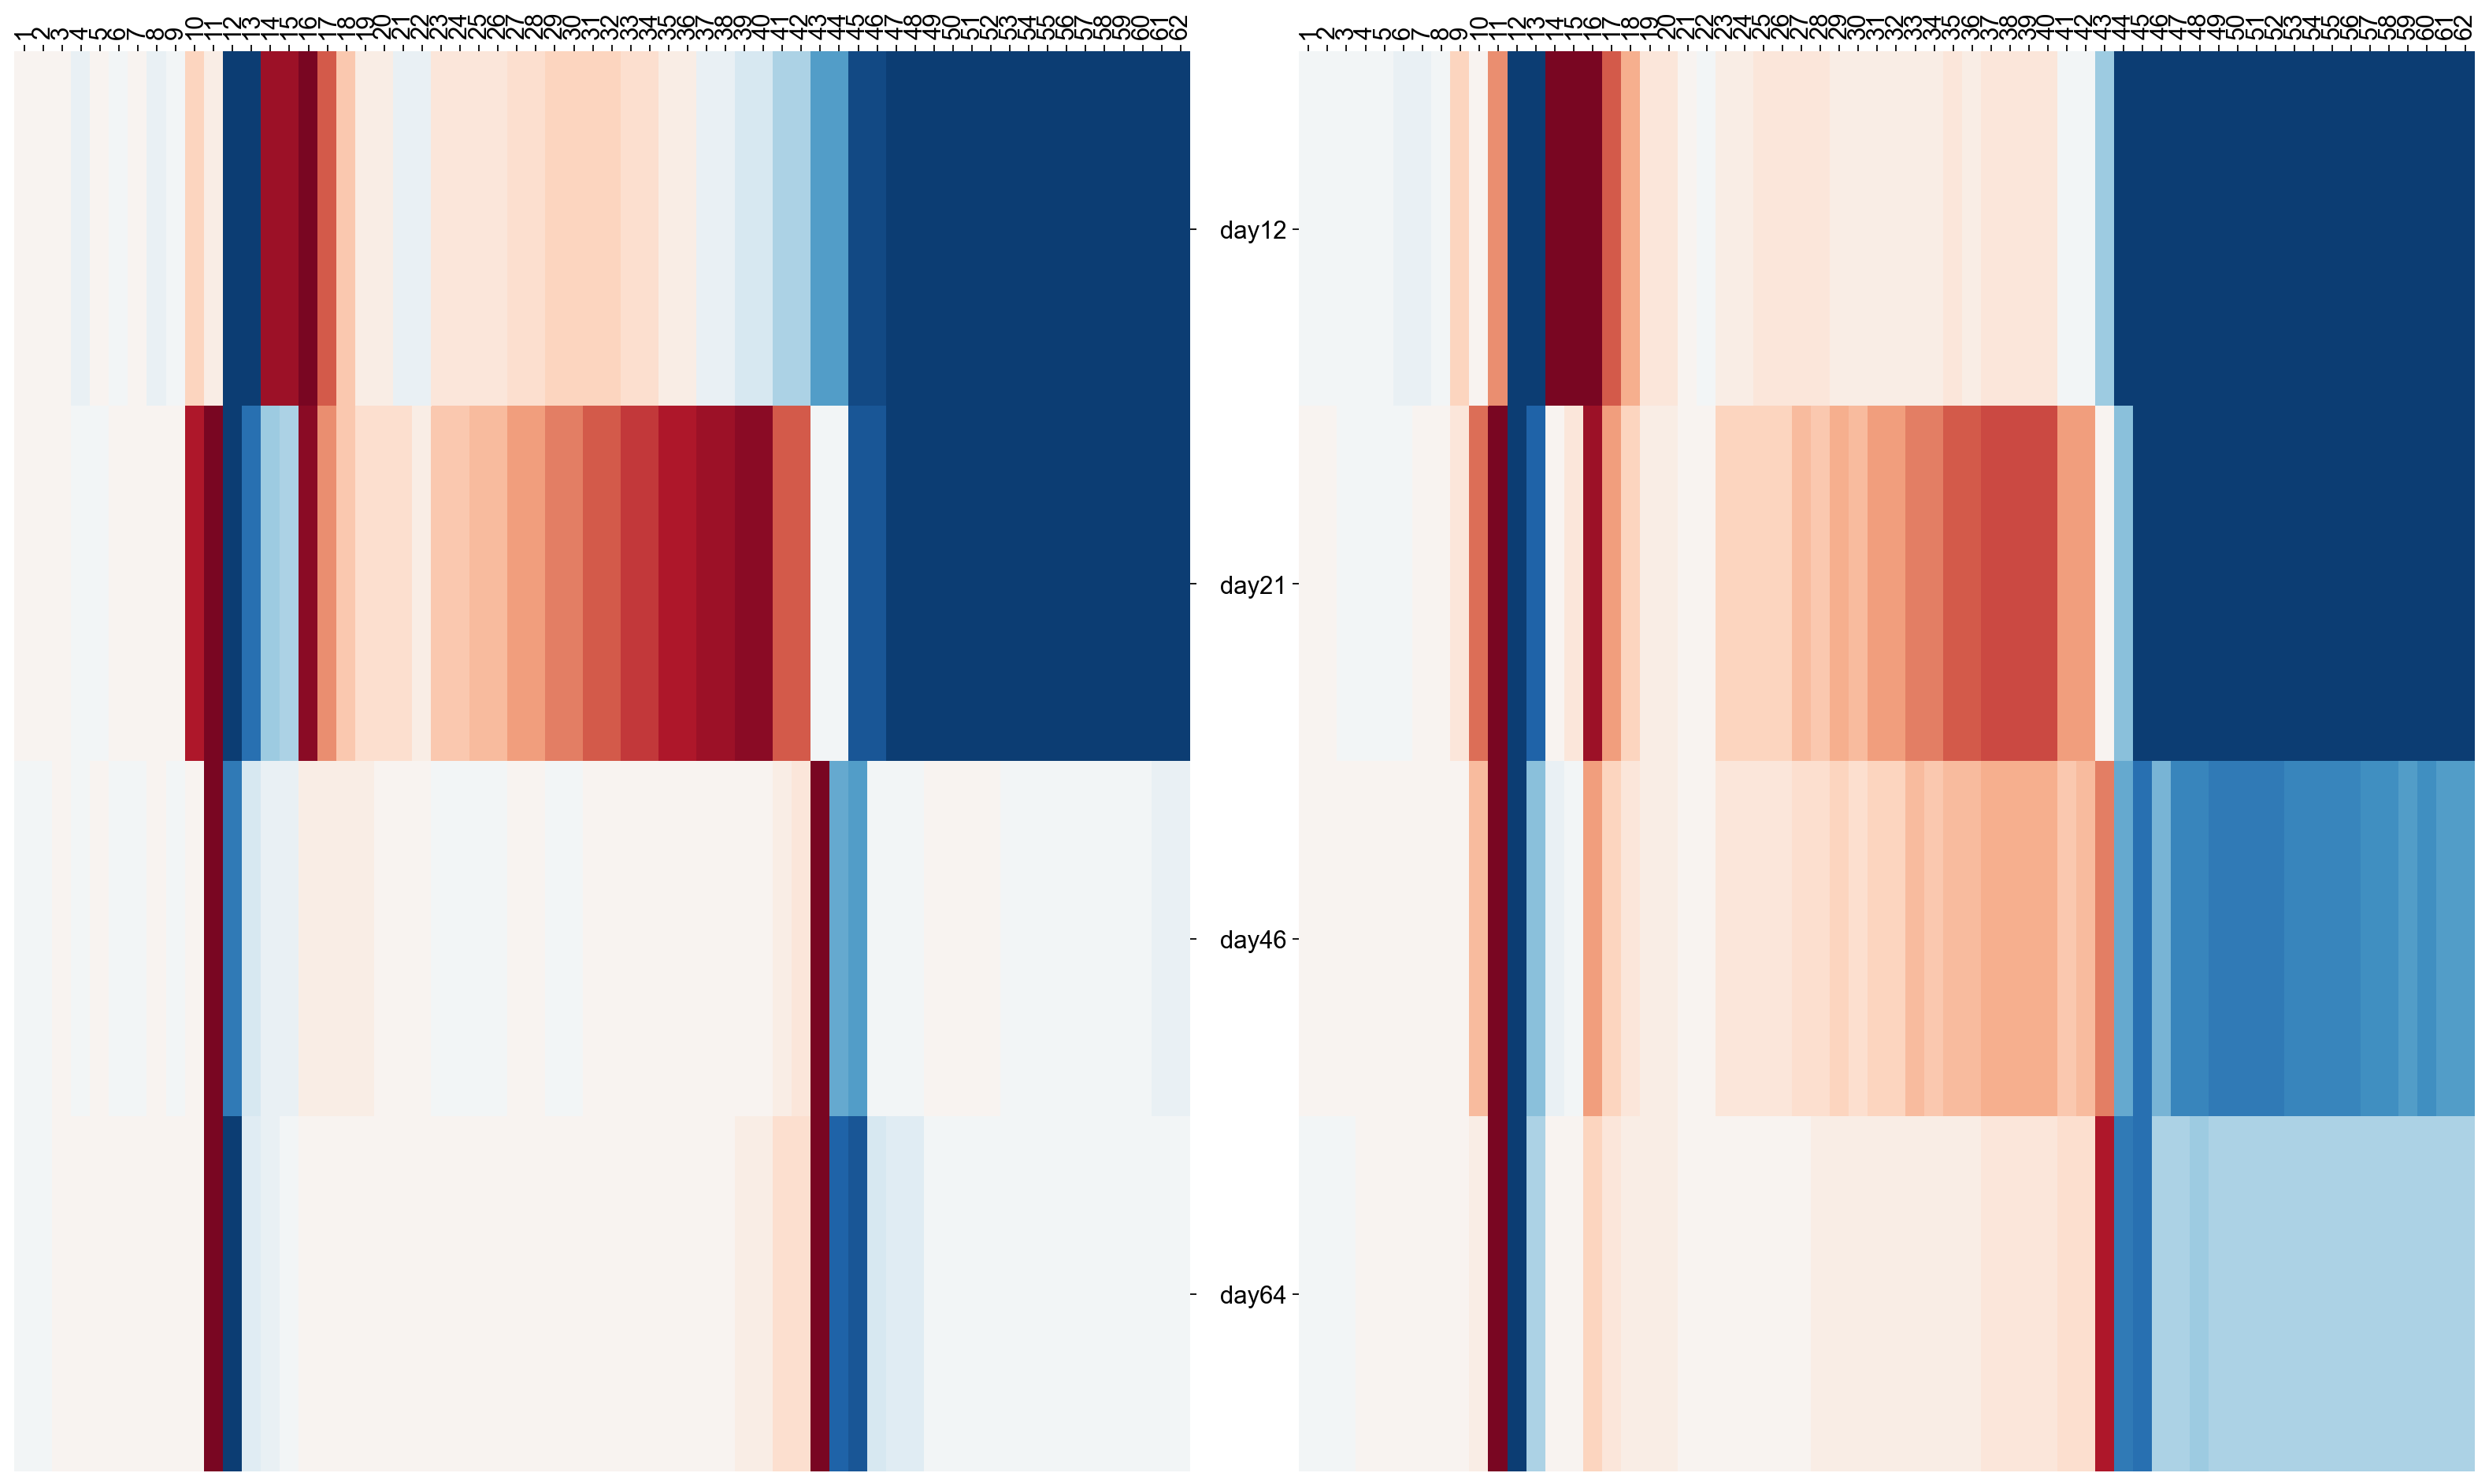

In [89]:
XT = XT_test
XE = XE_test
gene_4d_stage = gene_4d_stage_all[val_ind]
zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT_test,dtype=tf.float32), tf.constant(XE_test,dtype=tf.float32)), train_T=False, train_E=False)



true_vals = []
pred_vals = []
all_type = []
for t in gene_4d_stage_unq:
    this_type = gene_4d_stage==t
    if this_type.any():
        true_vals.append(np.mean(XE[this_type,:],axis=0))
        pred_vals.append(np.mean(np.array(XrE_cm)[this_type,:],axis=0))
        all_type.append(t)
    
true_vals = np.concatenate(np.expand_dims(true_vals,0),axis=0)
pred_vals = np.concatenate(np.expand_dims(pred_vals,0),axis=0)

M_true = (true_vals.T/np.max(true_vals,axis=1)).T
M_pred = (pred_vals.T/np.max(pred_vals,axis=1)).T


xlabels = np.arange(1,63).astype(str)

xname = [f.rstrip().lstrip() for f in xlabels]

# yname = [t for t in t_types]
# ydata = [f'{x:.2f}' for x in Pearson_R_per_type_E_to_T]
ylabels = all_type#[f'{a:<23s}'+f'{b:>4s}' for (a,b) in zip(yname,ydata)]


plt.figure(figsize = (20,12))
ax = plt.subplot(1,2,1)
sns.heatmap(M_true,annot=False,vmin=-1,vmax=1,center=0,cbar=False,
            cmap=sns.color_palette("RdBu_r", 40),ax=ax)

ax.set_yticks(np.arange(0,M_true.shape[0])+0.5)
ax.set_yticklabels(['']*len(ylabels),rotation=0)


ax.set_xticks(np.arange(M_true.shape[1])+0.5)
ax.set_xticklabels(xlabels,rotation=90)
ax.xaxis.set_ticks_position('top')
ax.yaxis.set_ticks_position('right')

ax = plt.subplot(1,2,2)
sns.heatmap(M_pred,annot=False,vmin=-1,vmax=1,center=0,cbar=False,
            cmap=sns.color_palette("RdBu_r", 40),ax=ax)

ax.set_yticks(np.arange(0,M_pred.shape[0])+0.5)
ax.set_yticklabels(ylabels,rotation=0)
ax.set_xticks(np.arange(M_pred.shape[1])+0.5)
ax.set_xticklabels(xlabels,rotation=90)
ax.xaxis.set_ticks_position('top')
ax.yaxis.set_ticks_position('left')
plt.tight_layout()
plt.savefig('./singlecellfigures/Testing4DayEphysAverageReconstructionSingeCell.pdf')



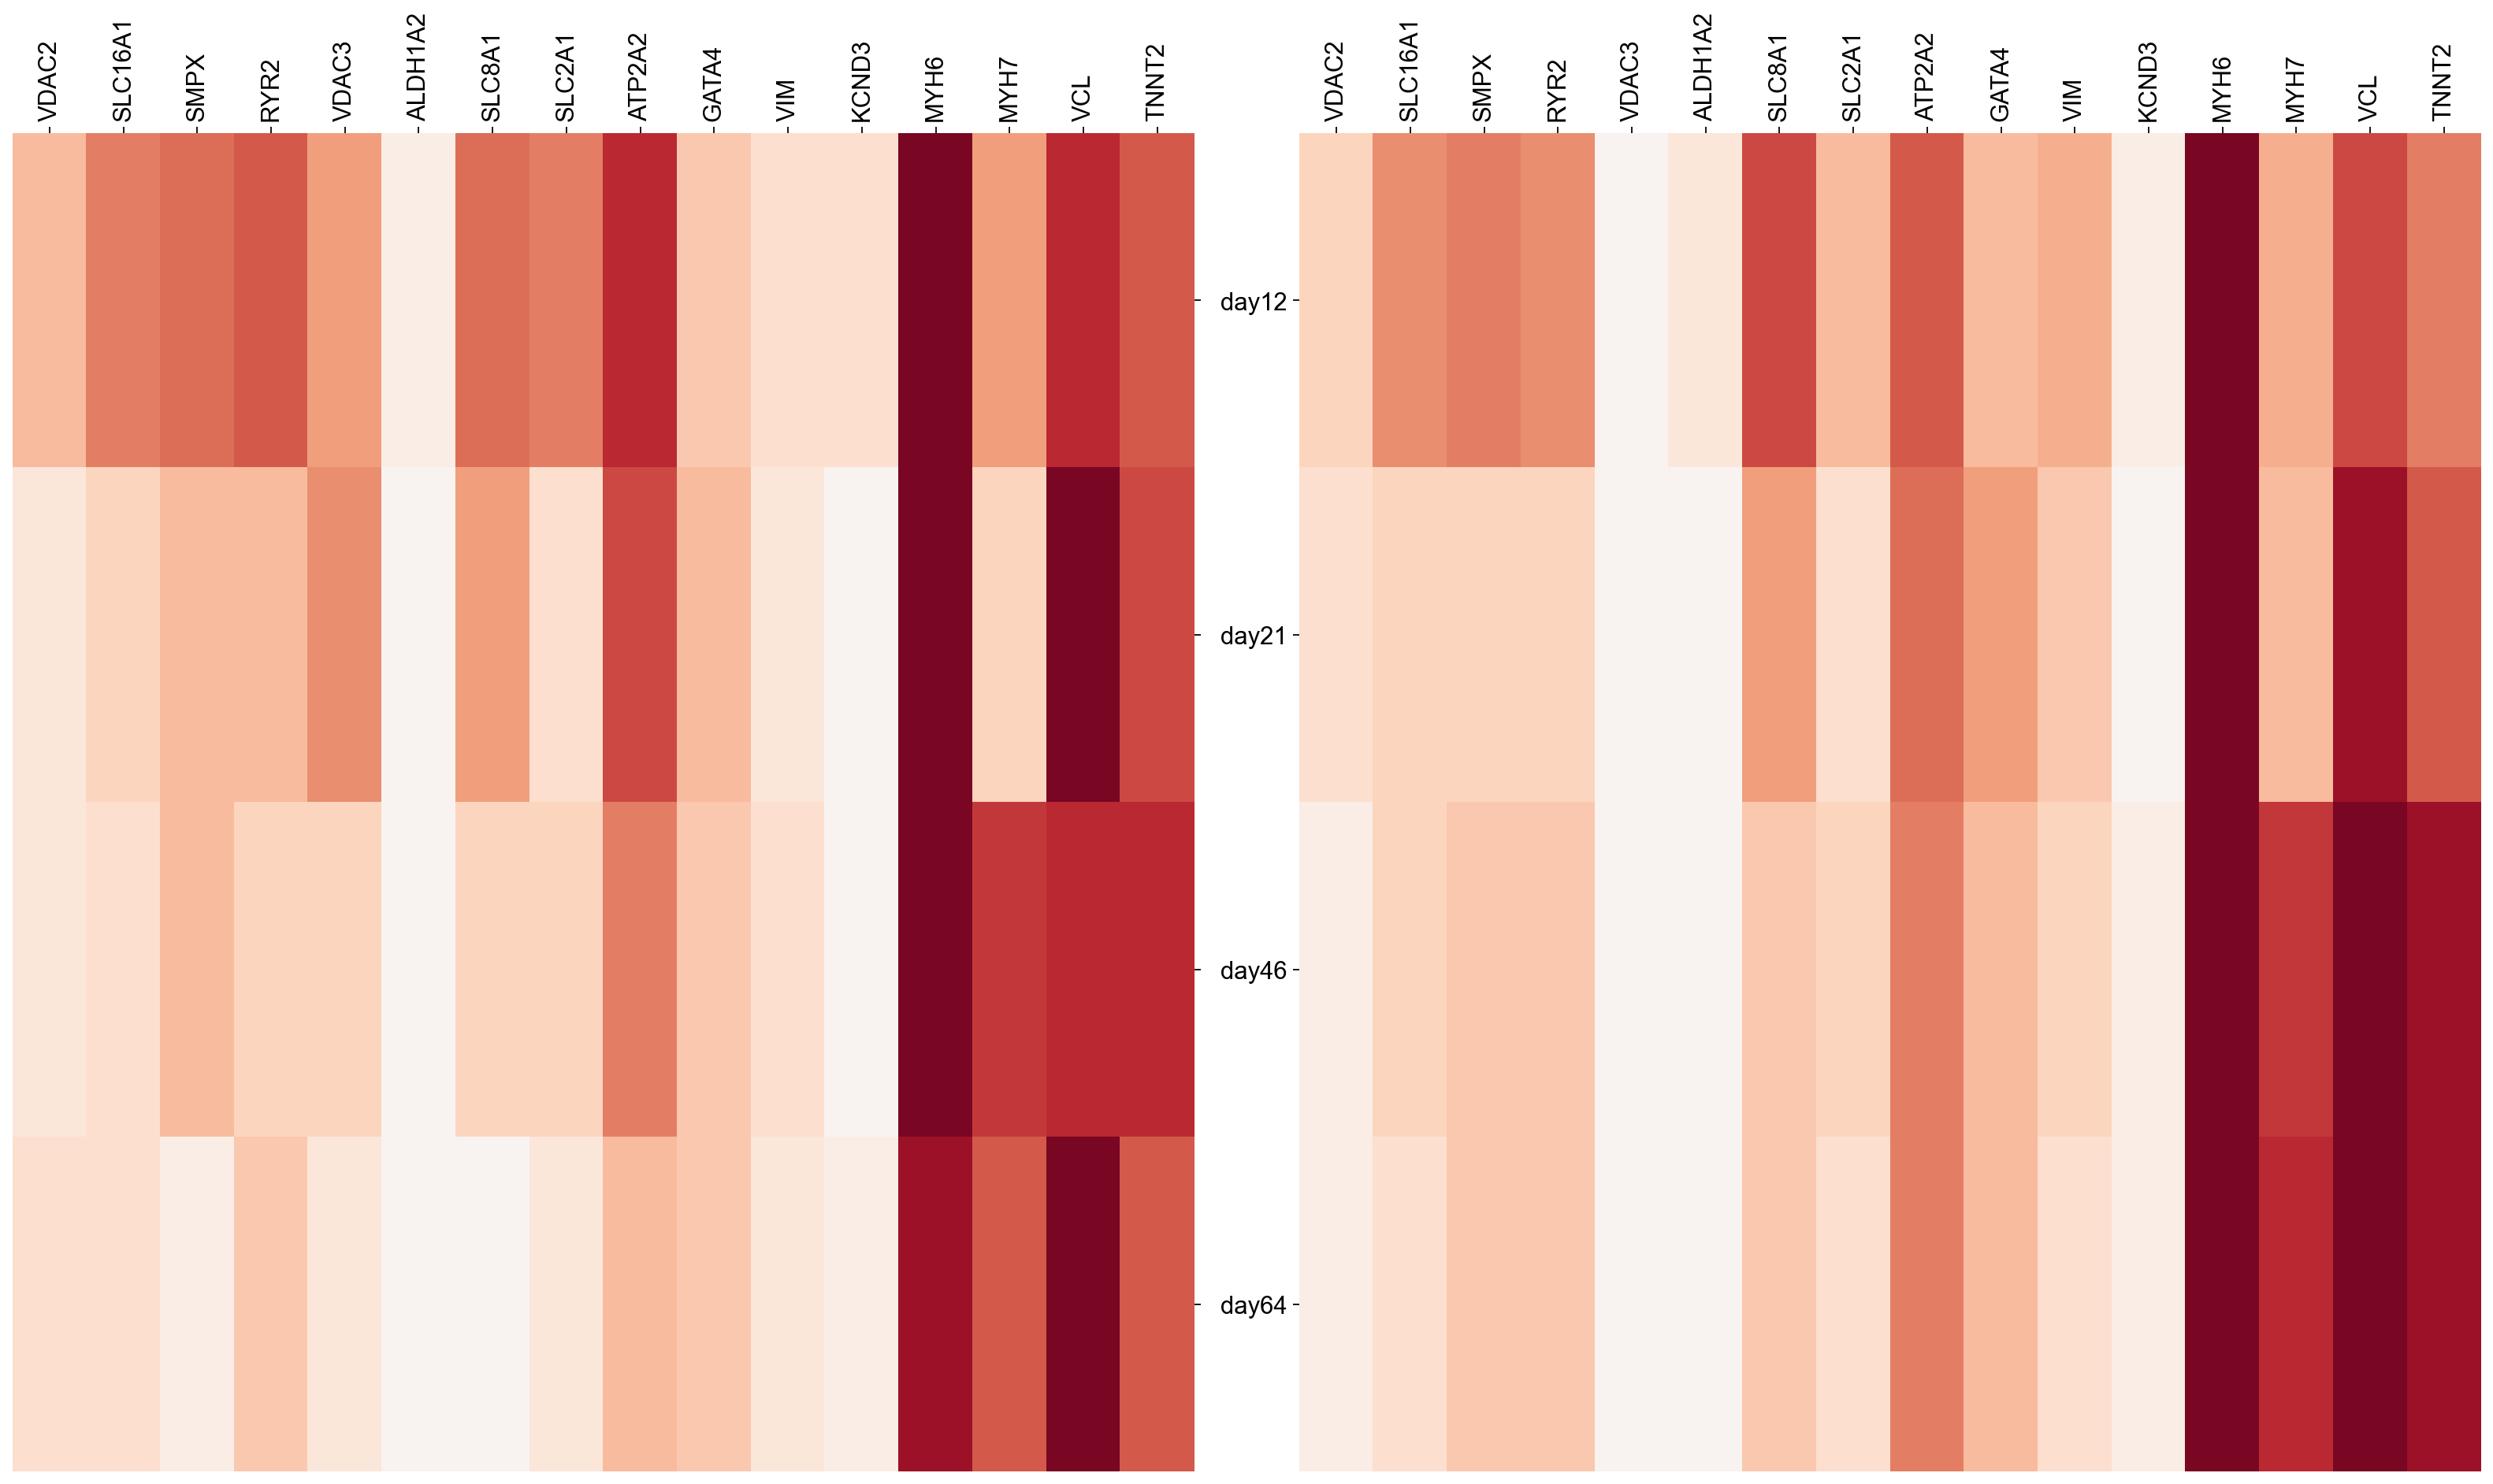

In [88]:
XT = XT_test
XE = XE_test
gene_4d_stage = gene_4d_stage_all[val_ind]
zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)

true_vals = []
pred_vals = []
all_type = []
for t in gene_4d_stage_unq:
    this_type = gene_4d_stage==t
    if this_type.any():
        true_vals.append(np.mean(XT[this_type,:],axis=0))
        pred_vals.append(np.mean(np.array(XrT_cm)[this_type,:],axis=0))
        all_type.append(t)
    
true_vals = np.concatenate(np.expand_dims(true_vals,0),axis=0)
pred_vals = np.concatenate(np.expand_dims(pred_vals,0),axis=0)
def reconplot(gene_inds,genes_found):
    M_true = (true_vals[:,gene_inds].T/np.max(true_vals[:,gene_inds],axis=1)).T
    M_pred = (pred_vals[:,gene_inds].T/np.max(pred_vals[:,gene_inds],axis=1)).T


    xlabels = genes_found

    xname = [f.rstrip().lstrip() for f in xlabels]

    # yname = [t for t in t_types]
    # ydata = [f'{x:.2f}' for x in Pearson_R_per_type_E_to_T]
    ylabels = all_type#[f'{a:<23s}'+f'{b:>4s}' for (a,b) in zip(yname,ydata)]


    plt.figure(figsize = (20,12))
    ax = plt.subplot(1,2,1)
    sns.heatmap(M_true,annot=False,vmin=-1,vmax=1,center=0,cbar=False,
                cmap=sns.color_palette("RdBu_r", 40),ax=ax)

    ax.set_yticks(np.arange(0,M_true.shape[0])+0.5)
    ax.set_yticklabels(['']*len(ylabels),rotation=0)


    ax.set_xticks(np.arange(M_true.shape[1])+0.5)
    ax.set_xticklabels(xlabels,rotation=90)
    ax.xaxis.set_ticks_position('top')
    ax.yaxis.set_ticks_position('right')

    ax = plt.subplot(1,2,2)
    sns.heatmap(M_pred,annot=False,vmin=-1,vmax=1,center=0,cbar=False,
                cmap=sns.color_palette("RdBu_r", 40),ax=ax)

    ax.set_yticks(np.arange(0,M_pred.shape[0])+0.5)
    ax.set_yticklabels(ylabels,rotation=0)
    ax.set_xticks(np.arange(M_pred.shape[1])+0.5)
    ax.set_xticklabels(xlabels,rotation=90)
    ax.xaxis.set_ticks_position('top')
    ax.yaxis.set_ticks_position('left')
    plt.tight_layout()
# reconplot(gene_inds_cor,genes_found_cor)
# plt.savefig('./figures/Training4DayGeneAverageReconstructionCMcorrelated.pdf')
reconplot(gene_inds_ion,genes_found_ion)
plt.savefig('./singlecellfigures/Testing4DayGeneAverageReconstructionRRRSinglecell.pdf')
# reconplot(gene_inds_spe,genes_found_spe)
# plt.savefig('./figures/Training4DayGeneAverageReconstructionSpeGenes.pdf')

# long term recording

Train      Epoch:    0, mse_T: 0.308, mse_E: 0.838, mse_TE: 1.833
Val.       Epoch:    0, mse_T: 0.331, mse_E: 0.640, mse_TE: 2.031
Train      Epoch:    1, mse_T: 0.294, mse_E: 0.603, mse_TE: 0.846
Val.       Epoch:    1, mse_T: 0.319, mse_E: 0.450, mse_TE: 0.885
Train      Epoch:    2, mse_T: 0.290, mse_E: 0.622, mse_TE: 2.227
Val.       Epoch:    2, mse_T: 0.315, mse_E: 0.398, mse_TE: 1.277
Train      Epoch:    3, mse_T: 0.295, mse_E: 0.346, mse_TE: 1.670
Val.       Epoch:    3, mse_T: 0.324, mse_E: 0.284, mse_TE: 1.728
Train      Epoch:    4, mse_T: 0.281, mse_E: 0.312, mse_TE: 0.684
Val.       Epoch:    4, mse_T: 0.311, mse_E: 0.258, mse_TE: 0.979
Train      Epoch:    5, mse_T: 0.279, mse_E: 0.317, mse_TE: 0.336
Val.       Epoch:    5, mse_T: 0.311, mse_E: 0.260, mse_TE: 0.692
Train      Epoch:    6, mse_T: 0.284, mse_E: 1.704, mse_TE: 3.242
Val.       Epoch:    6, mse_T: 0.319, mse_E: 1.824, mse_TE: 5.534
Train      Epoch:    7, mse_T: 0.279, mse_E: 0.463, mse_TE: 0.379
Val.      

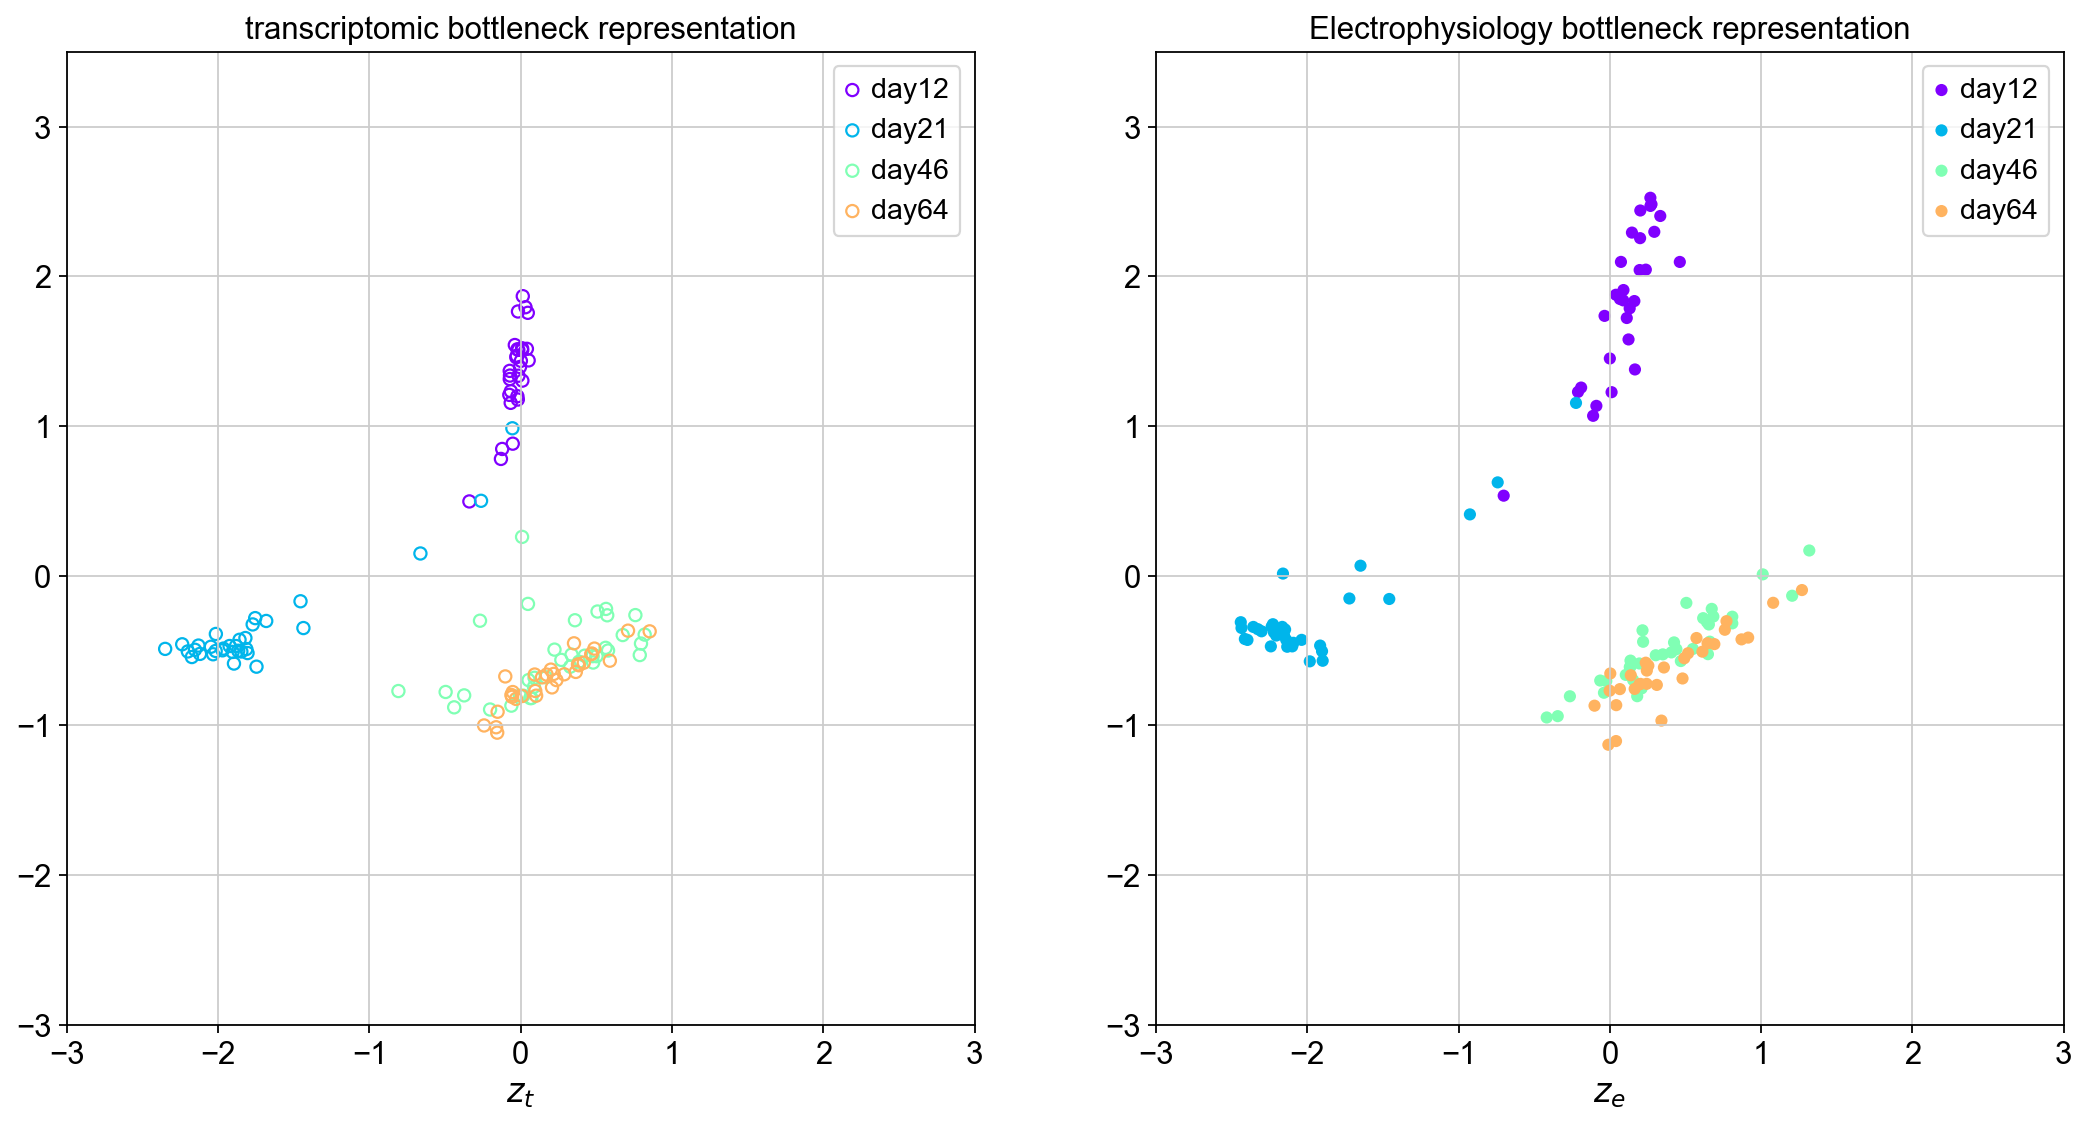

0.9403491287607749 129
0.627400627711849 129
0.922747995146529 129
0.628200013242428 129
0.9403491287607749 129
0.6273293526867941 129
0.922747995146529 129
0.628100950384805 129
0.9403491287607749 129
0.7542973863002871 129
0.922747995146529 129
0.7551788913325552 129
0.9403491287607749 129
0.7434061001163225 129
0.922747995146529 129
0.743757720461315 129


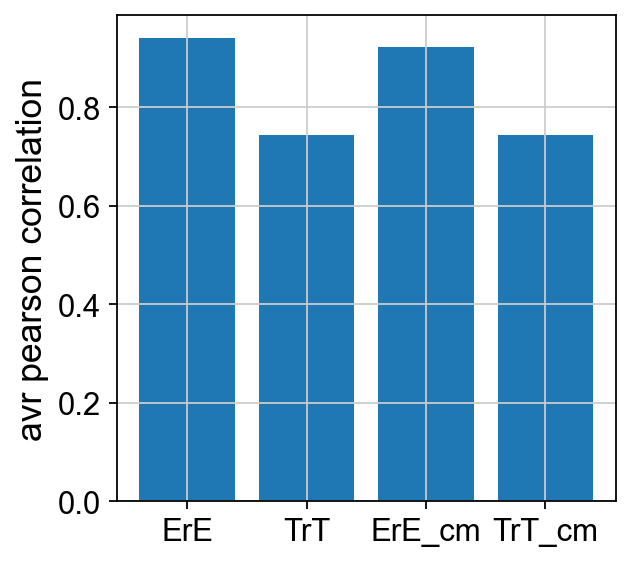

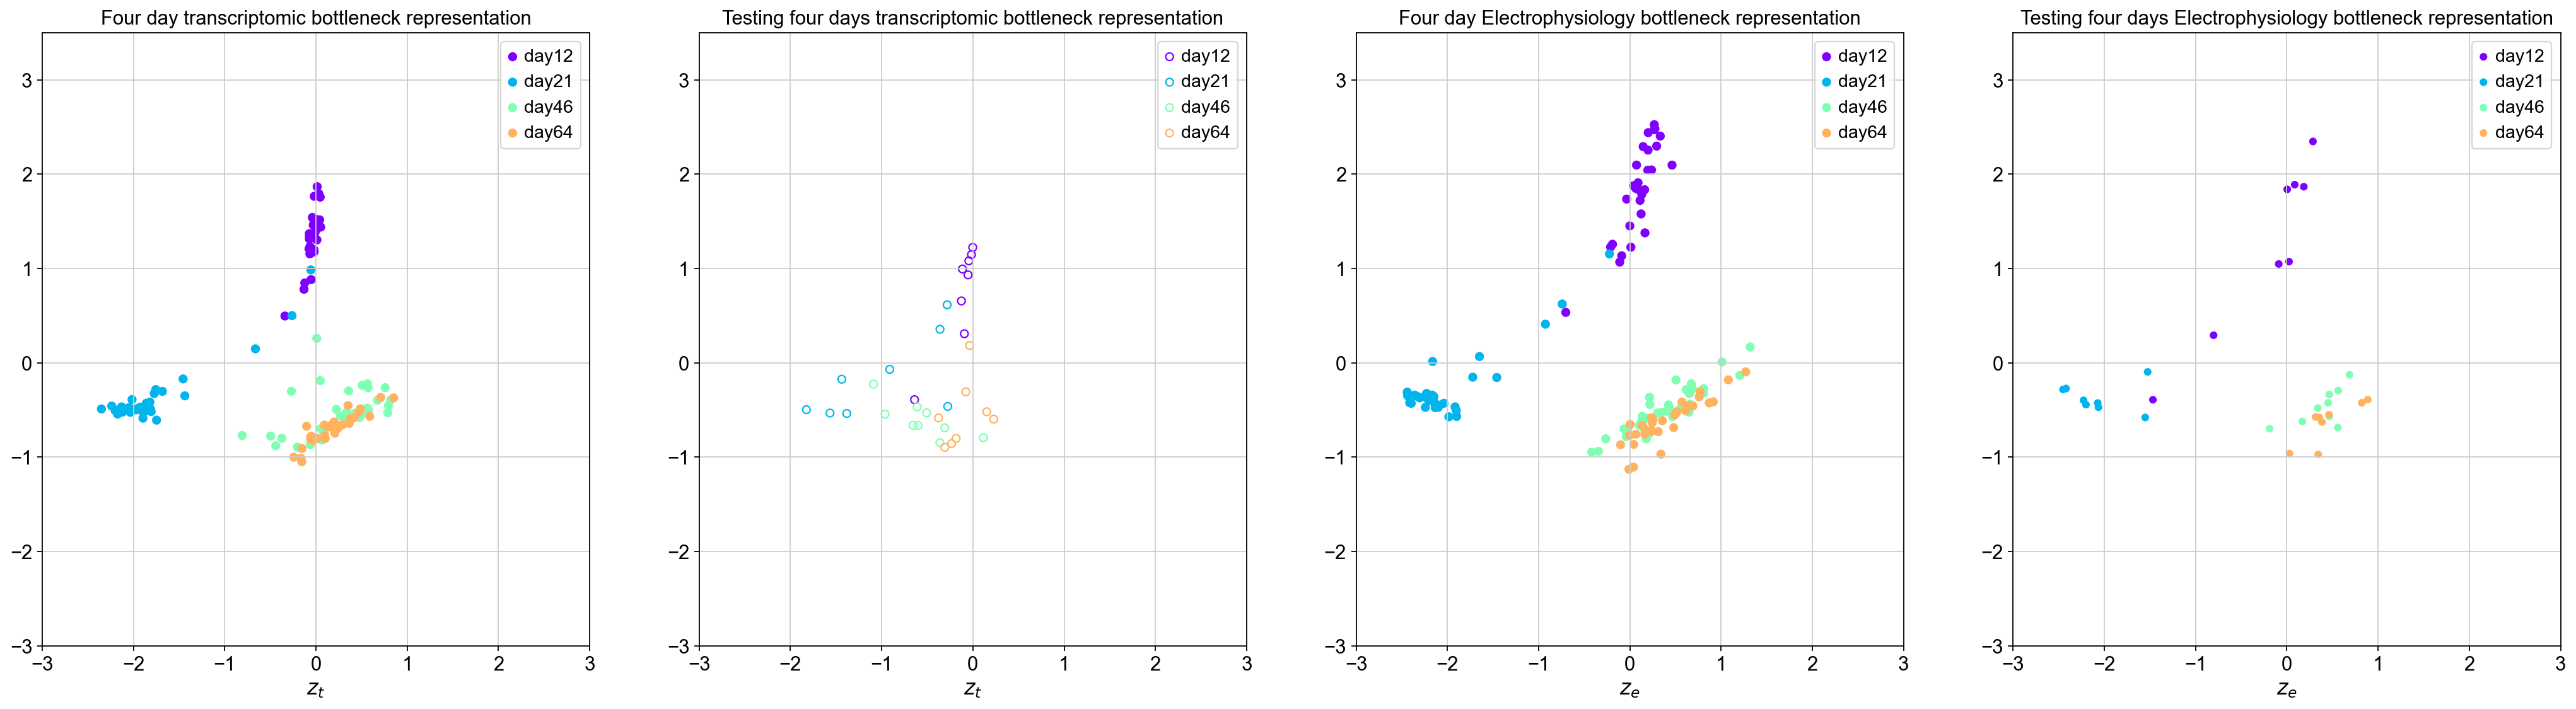

0.949256218578727 33
0.5895676343059622 33
0.8116699417913601 33
0.5873827467757242 33
0.949256218578727 33
0.5867061782473516 33
0.8116699417913601 33
0.5874837830383524 33
0.949256218578727 33
0.7255691462155051 33
0.8116699417913601 33
0.7341385762378093 33
0.949256218578727 33
0.7167419038975271 33
0.8116699417913601 33
0.7221682419242792 33


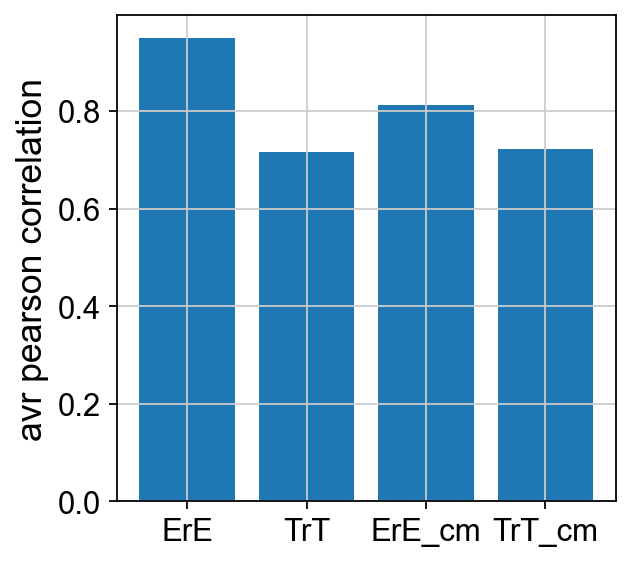

<ipython-input-51-8dab7ec02f75>:325: RuntimeWarning: invalid value encountered in log1p
  XT_test2 = np.log1p(XT_test2)


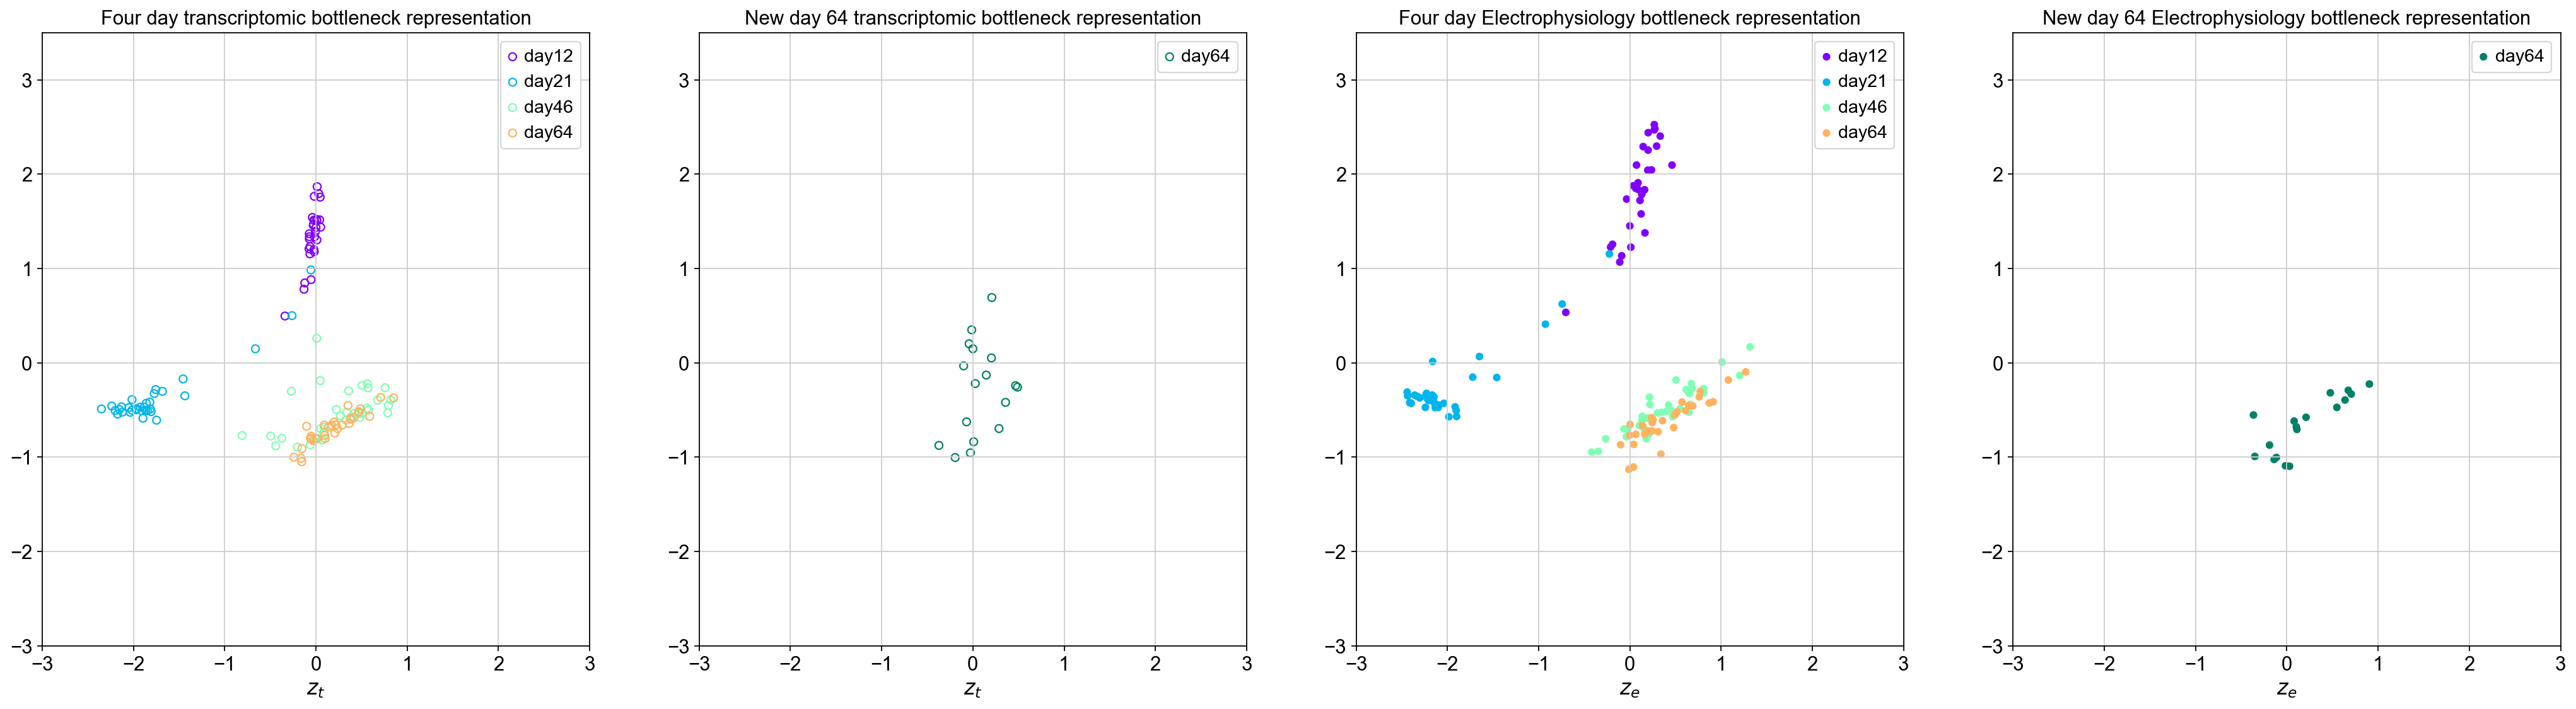

nan 17
0.4866264373333933 17
nan 17
0.49942388194681786 17
nan 17
0.5011505278178545 17
nan 17
0.530653693374513 17
nan 17
0.6492739752895137 17
nan 17
0.7005923388360508 17
nan 17
0.6197013522056111 17
nan 17
0.6594800527507786 17


/Users/tangxin/opt/anaconda3/envs/electroseq2/lib/python3.8/site-packages/numpy/lib/function_base.py:2559: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/tangxin/opt/anaconda3/envs/electroseq2/lib/python3.8/site-packages/numpy/lib/function_base.py:2560: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


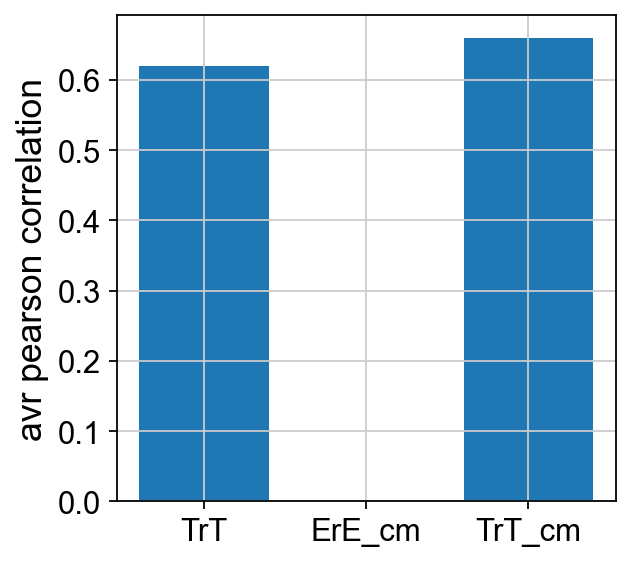

In [51]:

gene_train_4d_df = pd.read_csv('./data/contact_data/gene_data_dpc.csv',header=0,index_col=0)
gene_names = gene_train_4d_df.index

gene_4d_stage_all = np.array([vl.split('_')[0] for vl in gene_train_4d_df.columns.values])
gene_4d_stage_unq = np.unique(gene_4d_stage_all)
gene_4d_cl = color_cm('rainbow',len(gene_4d_stage_unq))
stage_cl = dict(zip(gene_4d_stage_unq,gene_4d_cl))
# gene_4d_stage_cl = np.vectorize(stage_cl.get)(gene_4d_stage_all)
gene_train_4d = gene_train_4d_df.values.T
ephys_train_4d = pd.read_csv('./data/contact_data/ephys_data_dpc.csv',header=0,index_col=0).values.T

ind_dict = partitions(gene_4d_stage_all, n_partitions=5, seed=0)
cor_ErE = []
cor_TrT = []
cor_ErE_cm = []
cor_TrT_cm = []
data_in = []
cv_all = []
method = []

for cv in range(1):
    stage_cl = dict(zip(gene_4d_stage_unq,gene_4d_cl))


    train_ind, val_ind = ind_dict[cv]['train'], ind_dict[cv]['val']
    XT = gene_train_4d[train_ind,:]
    XT_test = gene_train_4d[val_ind,:]

    XE = ephys_train_4d[train_ind,:]
    XE_test = ephys_train_4d[val_ind,:]

    gene_4d_stage = gene_4d_stage_all[train_ind]
    gene_hb_stage = gene_4d_stage_all[val_ind]

    # XT, XT_test, XE, XE_test,gene_4d_stage,gene_hb_stage = train_test_split(
    #     gene_train_4d, ephys_train_4d,gene_4d_stage_all, test_size=0.2, random_state=42)
    gene_4d_stage_cl = np.vectorize(stage_cl.get)(gene_4d_stage)
    # XT = gene_train_4d
    # XE = ephys_train_4d

    median_T = np.median(XT.sum(axis=1))
    XT = XT/XT.sum(axis=1)[:, np.newaxis]*median_T
    XT = np.log1p(XT)
    XT = np.nan_to_num(XT)
    T_dim = XT.shape[1]
    E_dim = XE.shape[1]


    XT_test = XT_test/XT_test.sum(axis=1)[:, np.newaxis]*median_T
    XT_test = np.log1p(XT_test)
    XT_test = np.nan_to_num(XT_test)
    #Training step
    @tf.function
    def train_fn(model, optimizer, xt, xe):
        with tf.GradientTape() as tape:
            zT, zE, XrT, XrE, XrT_cm, XrE_cm = model((xt, xe),
                                    train_T=True, 
                                    train_E=True,
                                    augment_decoders=True)

            trainable_weights = [weight for weight in model.trainable_weights]
            loss = sum(model.losses)

        grads = tape.gradient(loss, trainable_weights)
        optimizer.apply_gradients(zip(grads, trainable_weights))
        return zT, zE, XrT, XrE 
    #Print losses calculated. These are MSE calculations that do not include the  
    def report_metrics(model, epoch, losstype):
        print('{:10s} Epoch:{:5d}, '
                'mse_T: {:0.3f}, '
                'mse_E: {:0.3f}, '
                'mse_TE: {:0.3f}'.format(losstype,epoch,
                                        model.mse_loss_T.numpy(),
                                        model.mse_loss_E.numpy(),
                                        model.mse_loss_TE.numpy()))
        return model.mse_loss_T.numpy()+model.mse_loss_E.numpy()+model.mse_loss_TE.numpy()
    def cal_correlation(XE, XT, XrE, XrT, XrE_cm, XrT_cm):
        ErE = []
        TrT = []
        ErE_cm = []
        TrT_cm = []
        XE = tf.where(tf.math.is_nan(XE), x=0.0, y=XE)
        for i in range(0, XE.shape[0]):
            ErE_cor = np.corrcoef(XE[i, :], XrE[i, :])
            TrT_cor = np.corrcoef(XT[i, :], XrT[i, :])
            ErE_cm_cor = np.corrcoef(XE[i, :], XrE_cm[i, :])
            TrT_cm_cor = np.corrcoef(XT[i, :], XrT_cm[i, :])
            ErE.append(ErE_cor[0, 1])
            TrT.append(TrT_cor[0, 1])
            ErE_cm.append(ErE_cm_cor[0, 1])
            TrT_cm.append(TrT_cm_cor[0, 1])
        print(sum(ErE) / len(ErE), len(ErE))
        print(sum(TrT) / len(TrT), len(TrT))
        print(sum(ErE_cm) / len(ErE_cm), len(ErE_cm))
        print(sum(TrT_cm) / len(TrT_cm), len(TrT_cm))
        cor_ErE = sum(ErE) / len(ErE)
        cor_TrT = sum(TrT) / len(TrT)
        cor_ErE_cm = sum(ErE_cm) / len(ErE_cm)
        cor_TrT_cm = sum(TrT_cm) / len(TrT_cm)
        return cor_ErE,cor_TrT,cor_ErE_cm,cor_TrT_cm
    ## train the model with no normalized data with correct pair

    # tf.config.run_functions_eagerly(True)
    from utils.dataset import load_bioarxiv_dataset,partitions, Datagen
    seed = 42
    tf.random.set_seed(seed)
    batchsize = 10
    n_epochs = 20
    n_steps_per_epoch = 1000
    maxsteps = n_epochs*n_steps_per_epoch

    #Load and build model
    cplAE = Model_TE_aug_decoders(T_dim,E_dim,latent_dim=2)
    cplAE = custom_build(cplAE,(T_dim,E_dim))

    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)#3)
    train_generator = tf.data.Dataset.from_generator(Datagen,output_types=(tf.float32, tf.float32),
                                                     args=(maxsteps,batchsize,XT,XE))
    epoch=0
    loss_train = []
    loss_val = []
    for step, (xT,xE) in enumerate(train_generator):
        train_fn(model=cplAE,optimizer=adam_optimizer,xt=xT,xe=xE)

        #Report training loss
        if (step+1) % n_steps_per_epoch == 0:
            cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), 
                  train_T=False, train_E=False)
            loss_train.append(report_metrics(model=cplAE ,epoch=epoch, losstype='Train'))

            cplAE((tf.constant(XT_test,dtype=tf.float32), tf.constant(XE_test,dtype=tf.float32)),
                  train_T=False, train_E=False)
            loss_val.append(report_metrics(model=cplAE ,epoch=epoch, losstype='Val.'))

            epoch=epoch+1


    zE_lim = [[-3,3],[-3,3.5]]
    zT_lim = zE_lim
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(16,8))
    sz=30
    plt.subplot(1,2,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_4d_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,2,2)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()
    plt.savefig(f'./singlecellfigures/Training4DayManifoldCV{cv}.pdf')
    plt.show()



    genes_found_cor,gene_inds_cor = findgenes(Most_correlated)
    genes_found_ion,gene_inds_ion = findgenes(ion_channel)
    genes_found_spe,gene_inds_spe = findgenes(spe_gene)

    gene_id_dict = {'all':np.arange(201),
                    'cor':gene_inds_cor,
                   'ion':gene_inds_ion,
                   'spe':gene_inds_spe}


    from scipy import stats
    XT1 = XT
    XE1 = XE
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm
    for dt in ['all','cor','ion','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('training')
        data_in.append(dt)
        cv_all.append(cv)

    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)
    plt.savefig(f'./singlecellfigures/Training4DayCorrelationCV{cv}.pdf')
    plt.show()
    metrics_df_training = pd.DataFrame({'trans/rec':['ErE','TrT','ErE_cm','TrT_cm'],
                              "Pearson's R":[cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_]})

    gene_hb_stage_unq = gene_4d_stage_unq
    gene_hb_stage_cl = np.vectorize(stage_cl.get)(gene_hb_stage)
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(32,8))
    sz=30
    plt.subplot(1,4,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz)
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Four day transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,4,3)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Four day Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()

    # gene_hb_stage_unq = ['day64']

    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT_test,dtype=tf.float32), tf.constant(XE_test,dtype=tf.float32)), train_T=False, train_E=False)

    zT = zT.numpy()
    zE = zE.numpy()
    #Plot representations
    # plt.figure(figsize=(16,8))

    plt.subplot(1,4,2)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_hb_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Testing four days transcriptomic bottleneck representation')
    plt.legend()
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.subplot(1,4,4)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_hb_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Testing four days Electrophysiology bottleneck representation')
    plt.legend()
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.savefig(f'./singlecellfigures/ValidationTestingFourdaysVerificationManifoldCV{cv}.pdf')
    plt.show()


    from scipy import stats
    XT1 = XT_test
    XE1 = XE_test
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm

    for dt in ['all','cor','ion','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('self-splitting')
        data_in.append(dt)
        cv_all.append(cv)


    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)

    plt.savefig(f'./singlecellfigures/ValidationTestingFourdaysCorrelationCV{cv}.pdf')
    plt.show()
    metrics_df_self_testing = pd.DataFrame({'trans/rec':['ErE','TrT','ErE_cm','TrT_cm'],
                              "Pearson's R":[cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_]})

    # testing new day 64 sample

    gene_train_hb_df = pd.read_csv('../SupplementaryExperiment/2_Cardiac Mixed sample/results/gene_data_dpc_device18_integrated.csv',header=0,index_col=0)
    gene_train_hb_df.columns = gene_names
    # gene_train_hb_df = gene_train_hb_df[rrr_genes]
    gene_train_hb_df.index=[f'day64_{i}' for i in range(17)]
    gene_hb_stage = np.array(gene_train_hb_df.shape[0]*['day64'])
    gene_hb_stage_unq = np.unique(gene_hb_stage)
    gene_hb_cl = color_cm('summer',len(gene_hb_stage_unq))
    stage_cl = dict(zip(gene_hb_stage_unq,gene_hb_cl))
    gene_hb_stage_cl = np.vectorize(stage_cl.get)(gene_hb_stage)

    gene_val_hb = gene_train_hb_df.values.T
    ephys_val_hb = pd.read_csv('../SupplementaryExperiment/2_Cardiac Mixed sample/results/ephys_data_dpc_device18_integrated.csv',header=0,index_col=0).values.T

    XT_test2 = gene_val_hb.T
    XE_test2 = ephys_val_hb.T

    XT_test2 = XT_test2/XT_test2.sum(axis=1)[:, np.newaxis]*median_T
    XT_test2 = np.log1p(XT_test2)
    XT_test2 = np.nan_to_num(XT_test2)
    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
    zT = zT.numpy()
    zE = zE.numpy()

    #Plot representations
    plt.figure(figsize=(32,8))
    sz=30
    plt.subplot(1,4,1)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_4d_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('Four day transcriptomic bottleneck representation')
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.legend()
    plt.subplot(1,4,3)
    for t in gene_4d_stage_unq:
        this_type = gene_4d_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('Four day Electrophysiology bottleneck representation')
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.legend()

    gene_hb_stage_unq = ['day64']

    zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT_test2,dtype=tf.float32), tf.constant(XE_test2,dtype=tf.float32)), train_T=False, train_E=False)

    zT = zT.numpy()
    zE = zE.numpy()
    #Plot representations
    # plt.figure(figsize=(16,8))

    plt.subplot(1,4,2)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zT[this_type,0],zT[this_type,1],
                   c='none',label=t,s=sz,edgecolors=gene_hb_stage_cl[this_type])
    ax = plt.gca()
    ax.set_xlabel(r'$z_t$',fontsize=15)
    ax.set_title('New day 64 transcriptomic bottleneck representation')
    plt.legend()
    plt.xlim(zT_lim[0])
    plt.ylim(zT_lim[1])
    plt.subplot(1,4,4)
    for t in gene_hb_stage_unq:
        this_type = gene_hb_stage==t
        plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_hb_stage_cl[this_type],label=t,s=sz,linewidths=0)
    ax = plt.gca()
    ax.set_xlabel(r'$z_e$',fontsize=15)
    ax.set_title('New day 64 Electrophysiology bottleneck representation')
    plt.legend()
    plt.xlim(zE_lim[0])
    plt.ylim(zE_lim[1])
    plt.savefig(f'./singlecellfigures/NewDay64VerificationManifoldCV{cv}.pdf')
    plt.show()

    XT1 = XT_test2
    XE1 = XE_test2
    XrE1 = XrE
    XrT1 = XrT
    XrE_cm1 = XrE_cm
    XrT_cm1 = XrT_cm
    for dt in ['all','cor','ion','spe']:
        cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_ = cal_correlation(XE1, XT1[:,gene_id_dict[dt]],
                                                                    XrE1, XrT1.numpy()[:,gene_id_dict[dt]],
                                                                    XrE_cm1, XrT_cm1.numpy()[:,gene_id_dict[dt]])
        cor_ErE.append(cor_ErE_)
        cor_TrT.append(cor_TrT_)
        cor_ErE_cm.append(cor_ErE_cm_)
        cor_TrT_cm.append(cor_TrT_cm_)
        method.append('new-day-64')
        data_in.append(dt)
        cv_all.append(cv)

    import matplotlib.pyplot as plt
    fig = plt.figure()
    plt.bar(x = ['ErE','TrT','ErE_cm','TrT_cm'],height = [cor_ErE_,cor_TrT_,cor_ErE_cm_,cor_TrT_cm_])
    plt.ylabel('avr pearson correlation', fontsize=16)

    plt.show()




In [53]:
ephys_train_lt_df = pd.read_csv('./data/ephys/Longterm_ephys_data_dpc.csv',header=0,index_col=0)
ephys_lt_stage = np.array([vl.split('_')[0] for vl in ephys_train_lt_df.columns.values])
ephys_lt_stage_unq = np.unique(ephys_lt_stage)
ephys_lt_cl = color_cm('ocean',len(ephys_lt_stage_unq))
stage_cl = dict(zip(ephys_lt_stage_unq,ephys_lt_cl))
ephys_lt_stage_cl = np.vectorize(stage_cl.get)(ephys_lt_stage)

XE_test1 = ephys_train_lt_df.values.T





In [9]:
zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((tf.constant(XT,dtype=tf.float32), tf.constant(XE,dtype=tf.float32)), train_T=False, train_E=False)
zT = zT.numpy()
zE = zE.numpy()

#Plot representations
plt.figure(figsize=(32,8))
sz=30
plt.subplot(1,4,1)
for t in gene_4d_stage_unq:
    this_type = gene_4d_stage==t
    plt.scatter(zT[this_type,0],zT[this_type,1],
               c='none',label=t,s=sz,edgecolors=gene_4d_stage_cl[this_type])
ax = plt.gca()
ax.set_xlabel(r'$z_t$',fontsize=15)
ax.set_title('Four Day transcriptomic bottleneck representation')
plt.xlim(zT_lim[0])
plt.ylim(zT_lim[1])
plt.legend()
plt.subplot(1,4,3)
for t in gene_4d_stage_unq:
    this_type = gene_4d_stage==t
    plt.scatter(zE[this_type,0],zE[this_type,1],c=gene_4d_stage_cl[this_type],label=t,s=sz,linewidths=0)
ax = plt.gca()
ax.set_xlabel(r'$z_e$',fontsize=15)
ax.set_title('Four Day Electrophysiology bottleneck representation')
plt.xlim(zE_lim[0])
plt.ylim(zE_lim[1])
plt.legend()



fake_T = tf.zeros(
    [XE_test1.shape[0],201], dtype=tf.dtypes.float32, name=None
)
_,_,_,_,XrT_cm,_ = cplAE((fake_T, tf.constant(XE_test1,dtype=tf.float32)), train_T=False, train_E=False)
zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((XrT_cm, tf.constant(XE_test1,dtype=tf.float32)), train_T=False, train_E=False)


zT = zT.numpy()
zE = zE.numpy()
#Plot representations
# plt.figure(figsize=(16,8))

plt.subplot(1,4,2)
for t in ephys_lt_stage_unq:
    this_type = ephys_lt_stage==t
    plt.scatter(zT[this_type,0],zT[this_type,1],
               c='none',label=t,s=sz,edgecolors=ephys_lt_stage_cl[this_type])
ax = plt.gca()
ax.set_xlabel(r'$z_t$',fontsize=15)
ax.set_title('Countinuous recording translated transcriptomic bottleneck representation')
plt.legend()
plt.xlim(zT_lim[0])
plt.ylim(zT_lim[1])
plt.subplot(1,4,4)
for t in ephys_lt_stage_unq:
    this_type = ephys_lt_stage==t
    plt.scatter(zE[this_type,0],zE[this_type,1],c=ephys_lt_stage_cl[this_type],label=t,s=sz)
ax = plt.gca()
ax.set_xlabel(r'$z_e$',fontsize=15)
ax.set_title('Countinuous recording Electrophysiology bottleneck representation')
plt.legend()
plt.xlim(zE_lim[0])
plt.ylim(zE_lim[1])
plt.savefig('./singlecellfigures/TestContineousVerificationManifold.pdf')
plt.show()

In [3]:
fake_T = tf.zeros(
    [XE_test1.shape[0],201], dtype=tf.dtypes.float32, name=None
)
_,_,_,_,XrT_cm,_ = cplAE((fake_T, tf.constant(XE_test1,dtype=tf.float32)), train_T=False, train_E=False)
zT,zE,XrT,XrE,XrT_cm,XrE_cm = cplAE((XrT_cm, tf.constant(XE_test1,dtype=tf.float32)), train_T=False, train_E=False)


XrT_cm_new = (np.array(XrT_cm).T/np.max(np.array(XrT_cm),axis=1)).T
gene_set = an.AnnData(XrT_cm.numpy())
gene_set.obs['stage']=ephys_lt_stage
gene_set.var_names=gene_train_4d_df.index.values
sc.tl.rank_genes_groups(gene_set, 'stage', method='wilcoxon')
sc.pl.rank_genes_groups(gene_set, n_genes=25, sharey=True,save = 'CountinousPredCellTypeCorrelatedGene.png')


In [8]:
sc.pl.heatmap(gene_set, ['VDAC2','SLC16A1','SMPX', 'RYR2', 'VDAC3',
                         'ALDH1A2','SLC8A1',  'SLC2A1', 'ATP2A2', 
         'GATA4','VIM', 'KCND3','MYH6','MYH7','VCL','TNNT2', ]
, log=True,groupby='stage',cmap='Reds',standard_scale='var'
              ,swap_axes=False,save='CountinousPredTypeallRRR.pdf')



